# Análisis Exploratorio de Datos: Elo Ratings del Mundial 2026

Este notebook realiza un Análisis Exploratorio de Datos (EDA) sobre el dataset
**"2026 FIFA World Cup — Historical Elo Ratings"**, que contiene 125 años
(1901-2026) de ratings Elo históricos para las 48 selecciones clasificadas al
Mundial 2026 (Estados Unidos, Canadá y México).

El Elo es un sistema de puntuación que mide la fuerza relativa de cada selección
en cada momento del tiempo. Cuanto más alto el rating, más fuerte se considera
el equipo en esa fecha.

## 1. Descripción del dataset

**Fuente:** [2026 FIFA World Cup — Historical Elo Ratings](https://www.kaggle.com/datasets/afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings)
(Kaggle), basado en datos de [eloratings.net](https://www.eloratings.net/).

**Fichero:** `elo_ratings_wc2026.csv` — 4.683 filas × 23 columnas, UTF-8.

Cada fila representa el estado de una selección al final de un año concreto
(`snapshot_date`), salvo la última fila de 2026 que es un snapshot "en vivo"
tomado el 27/05/2026.

### Diccionario de variables

| Columna | Tipo | Descripción |
|---|---|---|
| `year` | int | Año del snapshot |
| `snapshot_date` | fecha | Fecha exacta del snapshot |
| `country` | texto | Nombre actual de la selección |
| `country_code` | texto | Código de 2 letras (eloratings.net) |
| `rank` | int | Ranking Elo global en ese momento |
| `rating` | int | Rating Elo en ese momento |
| `rank_max` / `rating_max` | int | Mejor ranking / rating histórico hasta esa fecha |
| `rank_avg` / `rating_avg` | int | Ranking / rating medio histórico hasta esa fecha |
| `rank_min` / `rating_min` | int | Peor ranking / rating histórico hasta esa fecha |
| `matches_total` | int | Partidos internacionales acumulados |
| `matches_home/away/neutral` | int | Desglose de partidos por tipo de sede |
| `wins` / `losses` / `draws` | int | Resultados acumulados |
| `goals_for` / `goals_against` | int | Goles acumulados |
| `confederation` | texto | Confederación (UEFA, CONMEBOL, CAF, CONCACAF, AFC, OFC) |
| `is_host` | int | 1 si la selección es anfitriona del Mundial 2026 (USA, Canadá, México) |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de los gráficos
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

df = pd.read_csv('elo_ratings_wc2026.csv')
df.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


In [2]:
# Dimensiones del dataset y tipos de datos
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()

Filas: 4683, Columnas: 23
<class 'pandas.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   year             4683 non-null   int64
 1   snapshot_date    4683 non-null   str  
 2   country          4683 non-null   str  
 3   rank             4683 non-null   int64
 4   country_code     4683 non-null   str  
 5   rating           4683 non-null   int64
 6   rank_max         4683 non-null   int64
 7   rating_max       4683 non-null   int64
 8   rank_avg         4683 non-null   int64
 9   rating_avg       4683 non-null   int64
 10  rank_min         4683 non-null   int64
 11  rating_min       4683 non-null   int64
 12  matches_total    4683 non-null   int64
 13  matches_home     4683 non-null   int64
 14  matches_away     4683 non-null   int64
 15  matches_neutral  4683 non-null   int64
 16  wins             4683 non-null   int64
 17  losses           4683 non-null   int6

## 2. Limpieza de datos

### 2.1 Valores nulos

In [3]:
# Comprobamos si hay valores nulos en alguna columna
df.isnull().sum()

year               0
snapshot_date      0
country            0
rank               0
country_code       0
rating             0
rank_max           0
rating_max         0
rank_avg           0
rating_avg         0
rank_min           0
rating_min         0
matches_total      0
matches_home       0
matches_away       0
matches_neutral    0
wins               0
losses             0
draws              0
goals_for          0
goals_against      0
confederation      0
is_host            0
dtype: int64

No se ha encontrado ningún valor nulo en el dataset. No es necesario sustituir nada.

### 2.2 Duplicados

In [4]:
# Comprobamos duplicados exactos (filas completas idénticas)
print("Duplicados exactos:", df.duplicated().sum())

# Comprobamos duplicados a nivel (country, year): debería haber como máximo
# una fila por selección y año
dup_country_year = df.duplicated(subset=['country', 'year']).sum()
print("Duplicados (country, year):", dup_country_year)

Duplicados exactos: 0
Duplicados (country, year): 48


No hay filas exactamente duplicadas, pero existen **48 combinaciones
(country, year) duplicadas** — exactamente una por cada selección clasificada.
Vamos a investigar por qué.

In [5]:
# Inspeccionamos un caso concreto
df[(df['country'] == 'Argentina') & (df['year'] == 2026)]

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
4588,2026,2026-12-31,Argentina,2,AR,2113,1,2172,5,1987,...,381,419,309,610,228,271,2112,1136,CONMEBOL,0
4636,2026,2026-05-27,Argentina,2,AR,2113,1,2172,5,1987,...,381,419,309,610,228,271,2112,1136,CONMEBOL,0


Para el año 2026 cada selección tiene **dos filas idénticas**: una con
`snapshot_date = 2026-12-31` (placeholder de fin de año, ya que el año aún no
ha terminado) y otra con `snapshot_date = 2026-05-27` (snapshot "en vivo", la
fecha real de extracción de los datos). Ambas contienen los mismos valores.

**Tratamiento:** eliminamos la fila placeholder de fin de año 2026 y nos
quedamos con el snapshot "en vivo", que es la información más reciente
disponible antes del inicio del torneo.

In [6]:
# Eliminamos la fila placeholder de 2026-12-31 (duplicado del snapshot en vivo)
df = df[~((df['year'] == 2026) & (df['snapshot_date'] == '2026-12-31'))].reset_index(drop=True)

print("Nuevo shape:", df.shape)
print("Duplicados (country, year) restantes:", df.duplicated(subset=['country','year']).sum())

Nuevo shape: (4635, 23)
Duplicados (country, year) restantes: 0


### 2.3 Revisión de tipos de datos

In [7]:
# Convertimos snapshot_date a tipo datetime para poder trabajar con fechas
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
df.dtypes

year                        int64
snapshot_date      datetime64[us]
country                       str
rank                        int64
country_code                  str
rating                      int64
rank_max                    int64
rating_max                  int64
rank_avg                    int64
rating_avg                  int64
rank_min                    int64
rating_min                  int64
matches_total               int64
matches_home                int64
matches_away                int64
matches_neutral             int64
wins                        int64
losses                      int64
draws                       int64
goals_for                   int64
goals_against               int64
confederation                 str
is_host                     int64
dtype: object

Todas las columnas numéricas ya tienen el tipo `int64` correcto. La columna
`snapshot_date` ha sido convertida de texto a `datetime64`. Las columnas de
texto (`country`, `country_code`, `confederation`) son de tipo `object`, lo
cual es correcto.

### 2.4 Detección de datos erróneos (revisión de consistencia)

In [8]:
# Verificamos que wins + losses + draws coincide con matches_total
check_results = (df['wins'] + df['losses'] + df['draws'] == df['matches_total']).all()
print("¿wins + losses + draws == matches_total para todas las filas?", check_results)

# Verificamos que matches_home + matches_away + matches_neutral coincide con matches_total
check_venues = (df['matches_home'] + df['matches_away'] + df['matches_neutral'] == df['matches_total']).all()
print("¿matches_home + away + neutral == matches_total para todas las filas?", check_venues)

# Verificamos que no haya valores negativos en las columnas numéricas
numeric_cols = df.select_dtypes(include='int64').columns
negative_values = (df[numeric_cols] < 0).sum().sum()
print("Número de valores negativos en columnas numéricas:", negative_values)

¿wins + losses + draws == matches_total para todas las filas? True
¿matches_home + away + neutral == matches_total para todas las filas? True
Número de valores negativos en columnas numéricas: 0


Las tres comprobaciones de consistencia son correctas: no se ha encontrado
ningún dato erróneo o inconsistente. El dataset queda **limpio y listo** para
el análisis.

## 3. Acceso y transformación de los datos

En esta sección realizamos 10 operaciones de selección y transformación sobre
el dataset para demostrar el uso de las principales instrucciones de pandas.

**Pregunta 1:** Selecciona únicamente las columnas más relevantes para el análisis (`country`, `year`, `confederation`, `rating`, `rank`, `is_host`) y muestra las 5 primeras filas.

In [9]:
df[['country', 'year', 'confederation', 'rating', 'rank', 'is_host']].head()

,country,year,confederation,rating,rank,is_host
0,England,1901,UEFA,2013,1,0
1,Scotland,1901,UEFA,1973,2,0
2,Argentina,1902,CONMEBOL,2021,1,0
3,England,1902,UEFA,1995,2,0
4,Scotland,1902,UEFA,1983,3,0


**Pregunta 2:** Filtra el dataset para quedarte solo con el snapshot más reciente de cada selección (año 2026) — este será nuestro dataset "actual".

In [10]:
df_current = df[df['year'] == 2026].reset_index(drop=True)
print("Número de selecciones en df_current:", df_current.shape[0])
df_current.head()

Número de selecciones en df_current: 48


,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,2026,2026-05-27,Spain,1,ES,2165,1,2189,7,1946,...,340,302,138,461,138,181,1591,697,UEFA,0
1,2026,2026-05-27,Argentina,2,AR,2113,1,2172,5,1987,...,381,419,309,610,228,271,2112,1136,CONMEBOL,0
2,2026,2026-05-27,France,3,FR,2081,1,2135,16,1795,...,473,341,124,474,269,195,1706,1272,UEFA,0
3,2026,2026-05-27,England,4,EN,2020,1,2213,4,1983,...,509,524,127,683,215,262,2719,1118,UEFA,0
4,2026,2026-05-27,Brazil,5,BR,1984,1,2195,4,1998,...,372,346,347,670,172,223,2294,954,CONMEBOL,0


**Pregunta 3:** Crea una nueva columna `win_rate` que indique el porcentaje de partidos ganados sobre el total de partidos jugados.

In [11]:
df_current['win_rate'] = (df_current['wins'] / df_current['matches_total'] * 100).round(2)
df_current[['country', 'matches_total', 'wins', 'win_rate']].head()

,country,matches_total,wins,win_rate
0,Spain,780,461,59.10
1,Argentina,1109,610,55.00
2,France,938,474,50.53
3,England,1160,683,58.88
4,Brazil,1065,670,62.91


**Pregunta 4:** Usando `loc`, selecciona todas las selecciones de la confederación UEFA y muestra su nombre y rating actual.

In [12]:
df_current.loc[df_current['confederation'] == 'UEFA', ['country', 'rating']]

,country,rating
0,Spain,2165
2,France,2081
3,England,2020
5,Portugal,1984
7,Netherlands,1961
9,Croatia,1930
10,Germany,1923
11,Norway,1912
13,Turkey,1902
15,Switzerland,1889


**Pregunta 5:** Usando `iloc`, ordena el dataset por `rating` de forma descendente y muestra las 5 primeras filas (las 5 columnas iniciales).

In [13]:
df_sorted = df_current.sort_values('rating', ascending=False).reset_index(drop=True)
df_sorted.iloc[:5, :5]

,year,snapshot_date,country,rank,country_code
0,2026,2026-05-27,Spain,1,ES
1,2026,2026-05-27,Argentina,2,AR
2,2026,2026-05-27,France,3,FR
3,2026,2026-05-27,England,4,EN
4,2026,2026-05-27,Brazil,5,BR


**Pregunta 6:** Agrupa las selecciones por `confederation` y calcula el rating medio de cada confederación.

In [14]:
rating_by_conf = df_current.groupby('confederation')['rating'].mean().round(1).sort_values(ascending=False)
rating_by_conf

confederation
CONMEBOL    1955.0
UEFA        1891.7
AFC         1690.7
CONCACAF    1678.3
CAF         1667.5
OFC         1585.0
Name: rating, dtype: float64

**Pregunta 7:** Usando `sort_values`, obtén el top 10 de selecciones por rating actual.

In [15]:
top10 = df_current.sort_values('rating', ascending=False).head(10)
top10[['country', 'confederation', 'rating', 'rank']]

,country,confederation,rating,rank
0,Spain,UEFA,2165,1
1,Argentina,CONMEBOL,2113,2
2,France,UEFA,2081,3
3,England,UEFA,2020,4
4,Brazil,CONMEBOL,1984,5
5,Portugal,UEFA,1984,5
6,Colombia,CONMEBOL,1975,7
7,Netherlands,UEFA,1961,8
8,Ecuador,CONMEBOL,1933,9
9,Croatia,UEFA,1930,10


**Pregunta 8:** Usando `apply`, crea una nueva columna `tier` que clasifique a cada selección según su rating: 'Élite' (>2000), 'Fuerte' (1800-2000), 'Medio' (1600-1800) o 'Débil' (<1600).

In [16]:
def clasificar_tier(rating):
    if rating > 2000:
        return 'Élite'
    elif rating >= 1800:
        return 'Fuerte'
    elif rating >= 1600:
        return 'Medio'
    else:
        return 'Débil'

df_current['tier'] = df_current['rating'].apply(clasificar_tier)
df_current['tier'].value_counts()

tier
Fuerte    18
Medio     17
Débil      9
Élite      4
Name: count, dtype: int64

**Pregunta 9:** Filtra las selecciones anfitrionas del Mundial 2026 (`is_host == 1`) y muestra su información principal.

In [17]:
df_current[df_current['is_host'] == 1][['country', 'confederation', 'rating', 'rank', 'tier']]

,country,confederation,rating,rank,tier
18,Mexico,CONCACAF,1860,20,Fuerte
22,Canada,CONCACAF,1784,25,Medio
31,United States,CONCACAF,1721,41,Medio


**Pregunta 10:** Crea una nueva columna `decline` que mida la diferencia entre el rating máximo histórico (`rating_max`) y el rating actual (`rating`), y muestra las 5 selecciones con mayor caída respecto a su pico histórico.

In [18]:
df_current['decline'] = df_current['rating_max'] - df_current['rating']
df_current.sort_values('decline', ascending=False)[['country', 'rating_max', 'rating', 'decline']].head(5)

,country,rating_max,rating,decline
45,Ghana,1877,1503,374
47,Qatar,1771,1425,346
24,Scotland,2104,1767,337
44,South Africa,1847,1524,323
30,Czechia,2032,1726,306


## 4. Análisis de los datos

En esta sección formulamos y respondemos preguntas analíticas sobre el dataset.

### 4.1 ¿Qué confederación tiene el rating Elo medio más alto entre las 48 "
   "selecciones clasificadas al Mundial 2026?

In [19]:
rating_by_conf_sorted = df_current.groupby('confederation')['rating'].agg(['mean', 'count']).round(1)
rating_by_conf_sorted = rating_by_conf_sorted.sort_values('mean', ascending=False)
rating_by_conf_sorted

,mean,count
confederation,,
CONMEBOL,1955.0,6
UEFA,1891.7,16
AFC,1690.7,9
CONCACAF,1678.3,6
CAF,1667.5,10
OFC,1585.0,1


**Interpretación:** UEFA es, con diferencia, la confederación con el rating medio
más alto, lo cual es coherente con el hecho de que aporta 16 de las 48 plazas y
concentra a varias de las selecciones históricamente más fuertes del mundo
(Francia, España, Alemania, Inglaterra...). CONMEBOL, aunque tiene solo 6
selecciones, también presenta un rating medio elevado gracias a Argentina y Brasil.

### 4.2 ¿Existe una ventaja histórica de "anfitrión" visible en el rating Elo "
   "de Estados Unidos, Canadá y México?

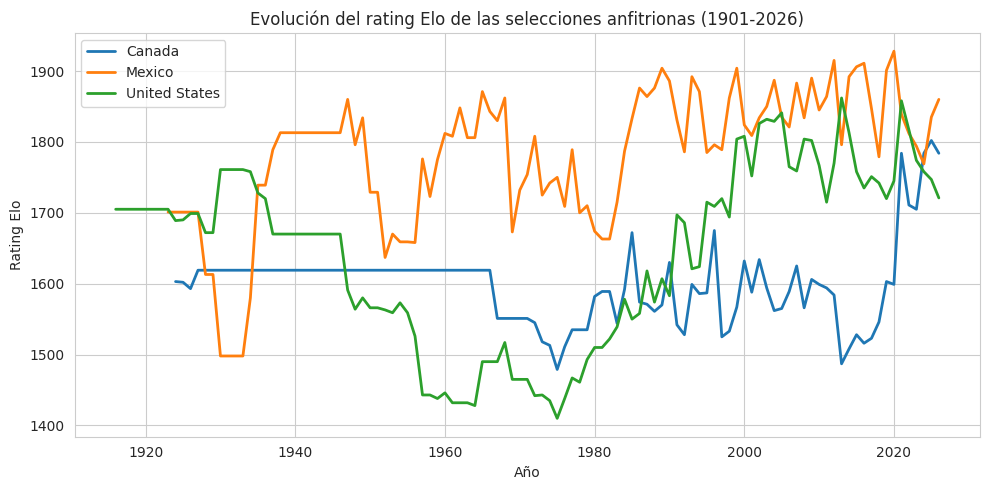

In [20]:
host_evolution = df[df['country'].isin(['United States', 'Canada', 'Mexico'])]

fig, ax = plt.subplots(figsize=(10, 5))
for country, group in host_evolution.groupby('country'):
    ax.plot(group['year'], group['rating'], label=country, linewidth=2)

ax.set_title('Evolución del rating Elo de las selecciones anfitrionas (1901-2026)')
ax.set_xlabel('Año')
ax.set_ylabel('Rating Elo')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** México muestra el rating históricamente más alto y estable
de los tres anfitriones, mientras que Estados Unidos presenta una clara tendencia
ascendente desde los años 90, coincidiendo con la profesionalización del fútbol
en el país (creación de la MLS en 1996). Canadá se mantiene en niveles más bajos
y estables, aunque con un repunte reciente. No se observa un "salto" anómalo
asociado únicamente a la designación como país anfitrión, sino tendencias de
fondo ya existentes.

### 4.3 ¿Qué selecciones presentan el mayor declive respecto a su pico histórico de Elo?

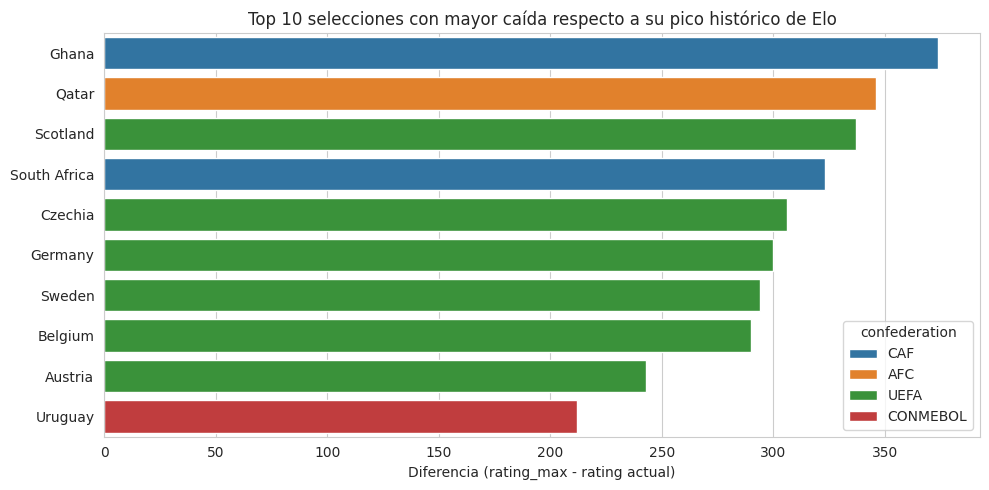

In [21]:
top_decline = df_current.sort_values('decline', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_decline, x='decline', y='country', hue='confederation', dodge=False, ax=ax)
ax.set_title('Top 10 selecciones con mayor caída respecto a su pico histórico de Elo')
ax.set_xlabel('Diferencia (rating_max - rating actual)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Interpretación:** Las selecciones con mayor declive suelen ser equipos que
vivieron una "época dorada" en el pasado (décadas con resultados excepcionales)
y que actualmente atraviesan un proceso de renovación generacional. Esto no
implica necesariamente debilidad para 2026, sino que su nivel actual está por
debajo de su techo histórico.

### 4.4 ¿Existe relación entre la experiencia internacional (`matches_total`) y la fuerza actual (`rating`)?

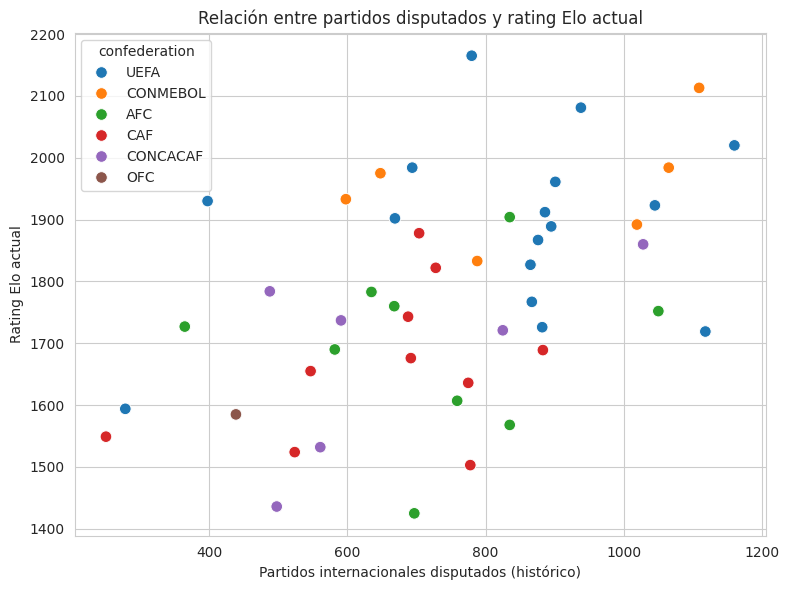

Correlación entre matches_total y rating: 0.479


In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df_current, x='matches_total', y='rating', hue='confederation', s=70, ax=ax)
ax.set_title('Relación entre partidos disputados y rating Elo actual')
ax.set_xlabel('Partidos internacionales disputados (histórico)')
ax.set_ylabel('Rating Elo actual')
plt.tight_layout()
plt.show()

correlacion = df_current['matches_total'].corr(df_current['rating'])
print(f"Correlación entre matches_total y rating: {correlacion:.3f}")

**Interpretación:** La correlación es positiva pero débil. Jugar muchos
partidos internacionales no garantiza un rating alto: selecciones con mucha
experiencia pero resultados modestos (por ejemplo, algunas históricas europeas
con federaciones muy antiguas) convive con selecciones jóvenes pero muy
competitivas. La experiencia es un factor secundario frente al nivel de
juego reciente.

### 4.5 ¿Cómo se posicionan las selecciones debutantes (Cabo Verde, Curaçao, Jordania, Uzbekistán) frente a la media del Mundial?

In [23]:
debutantes = ['Cape Verde', 'Curaçao', 'Jordan', 'Uzbekistan']

comparacion = pd.DataFrame({
    'Media de las 48 selecciones': [df_current['rating'].mean()],
    'Media de las debutantes': [df_current[df_current['country'].isin(debutantes)]['rating'].mean()]
}).round(1)

print(comparacion)
print()
print(df_current[df_current['country'].isin(debutantes)][['country', 'confederation', 'rating', 'rank', 'tier']]
      .sort_values('rating', ascending=False))

   Media de las 48 selecciones  Media de las debutantes
0                       1782.1                   1600.5

       country confederation  rating  rank   tier
29  Uzbekistan           AFC    1727    38  Medio
33      Jordan           AFC    1690    50  Medio
42  Cape Verde           CAF    1549    72  Débil
46     Curaçao      CONCACAF    1436    90  Débil


**Interpretación:** Las cuatro selecciones debutantes se sitúan claramente por
debajo de la media general del Mundial, lo cual es esperable: son selecciones
que históricamente no habían logrado clasificarse, por lo que su nivel medio es
inferior al de selecciones consolidadas. Aun así, ninguna de ellas se encuentra
en el escalón más bajo (`tier = 'Débil'`), lo que indica que su clasificación
no ha sido casual sino el resultado de una mejora real de nivel.

## 5. Visualización de datos

En esta sección presentamos seis gráficos adicionales que complementan el
análisis anterior, cada uno con su título, ejes identificados e interpretación.

### 5.1 Evolución histórica del rating Elo de las grandes selecciones (1990-2026)

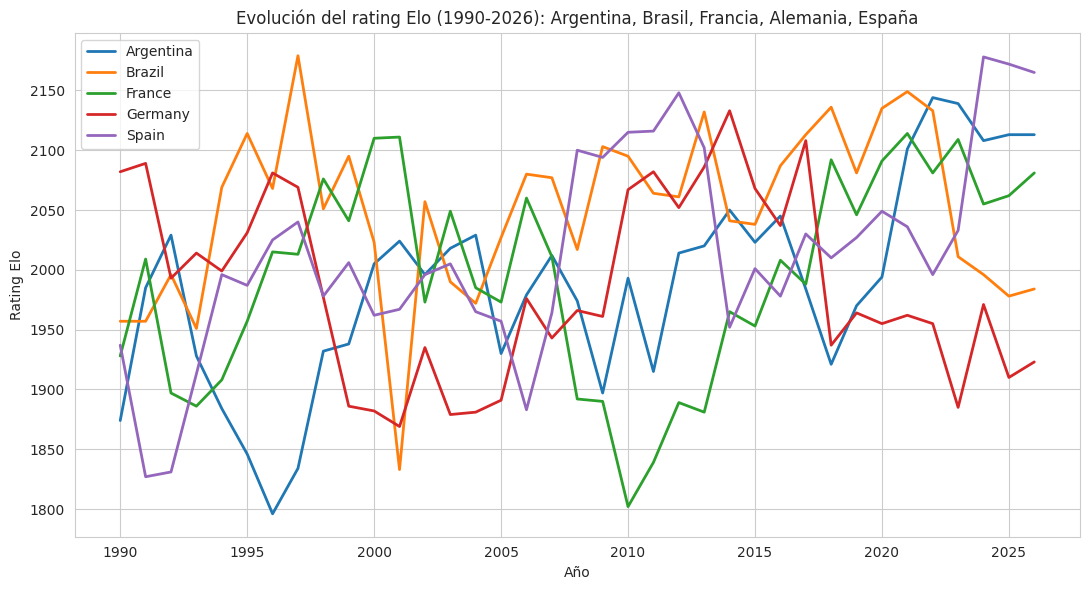

In [24]:
selected_teams = ['Argentina', 'Brazil', 'France', 'Germany', 'Spain']
df_selected = df[(df['country'].isin(selected_teams)) & (df['year'] >= 1990)]

fig, ax = plt.subplots(figsize=(11, 6))
for country, group in df_selected.groupby('country'):
    ax.plot(group['year'], group['rating'], label=country, linewidth=2)

ax.set_title('Evolución del rating Elo (1990-2026): Argentina, Brasil, Francia, Alemania, España')
ax.set_xlabel('Año')
ax.set_ylabel('Rating Elo')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** Se observan los grandes ciclos de éxito de cada selección:
el dominio de Brasil y Francia a finales de los 90 y 2000, el ascenso de España
hacia su pico en 2008-2012, y la consistencia de Alemania y Argentina con
fluctuaciones más recientes. De cara a 2026, España y Argentina llegan en una
fase ascendente, mientras que Alemania y Brasil muestran una tendencia más
plana en los últimos años.

### 5.2 Rating Elo medio por confederación (2026)

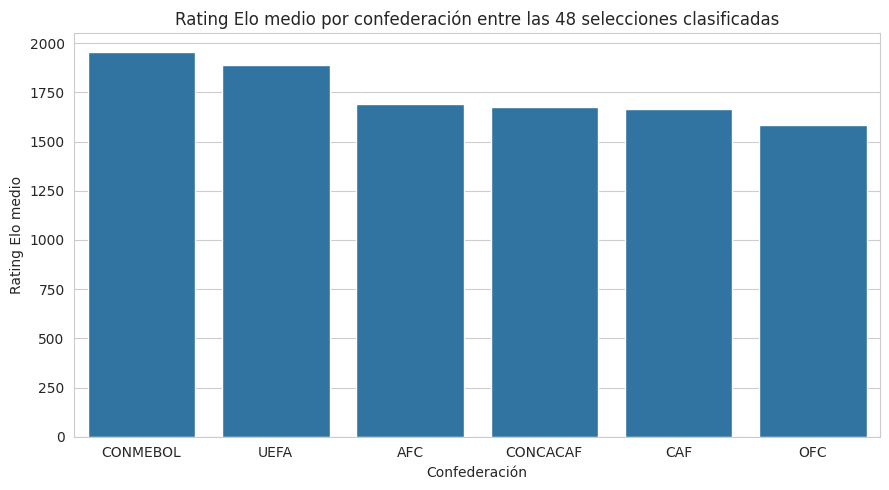

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df_current.groupby('confederation')['rating'].mean().sort_values(ascending=False).index
sns.barplot(data=df_current, x='confederation', y='rating', order=order, ax=ax, errorbar=None)
ax.set_title('Rating Elo medio por confederación entre las 48 selecciones clasificadas')
ax.set_xlabel('Confederación')
ax.set_ylabel('Rating Elo medio')
plt.tight_layout()
plt.show()

**Interpretación:** UEFA y CONMEBOL lideran claramente el rating medio, seguidas de cerca por AFC. OFC, representada por una única selección (Nueva Zelanda), presenta el valor más bajo.

### 5.3 Top 10 y Bottom 10 selecciones por rating actual

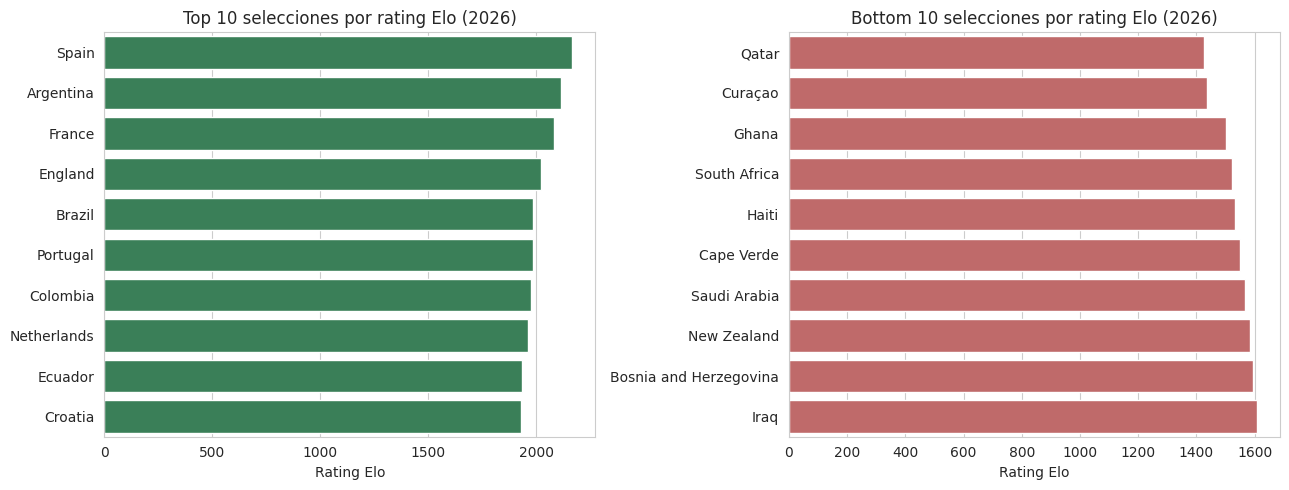

In [26]:
top10 = df_current.nlargest(10, 'rating')[['country', 'rating']]
bottom10 = df_current.nsmallest(10, 'rating')[['country', 'rating']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=top10, x='rating', y='country', ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 selecciones por rating Elo (2026)')
axes[0].set_xlabel('Rating Elo')
axes[0].set_ylabel('')

sns.barplot(data=bottom10, x='rating', y='country', ax=axes[1], color='indianred')
axes[1].set_title('Bottom 10 selecciones por rating Elo (2026)')
axes[1].set_xlabel('Rating Elo')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretación:** España, Argentina y Francia encabezan el ranking de las 48 clasificadas, mientras que Nueva Zelanda, Curaçao y Cabo Verde figuran entre las de menor rating, coherente con su condición de selecciones de confederaciones más pequeñas o debutantes.

### 5.4 Distribución de los ratings Elo de las 48 selecciones

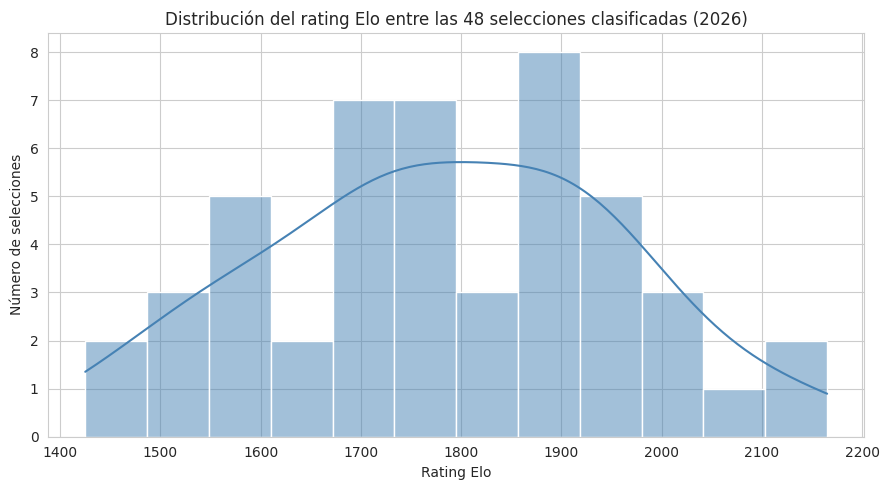

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_current['rating'], bins=12, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribución del rating Elo entre las 48 selecciones clasificadas (2026)')
ax.set_xlabel('Rating Elo')
ax.set_ylabel('Número de selecciones')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución muestra una concentración de selecciones en el rango 1700-1900, con una cola hacia la derecha formada por un grupo reducido de selecciones de élite (rating > 2000).

### 5.5 Relación entre experiencia internacional y rating actual

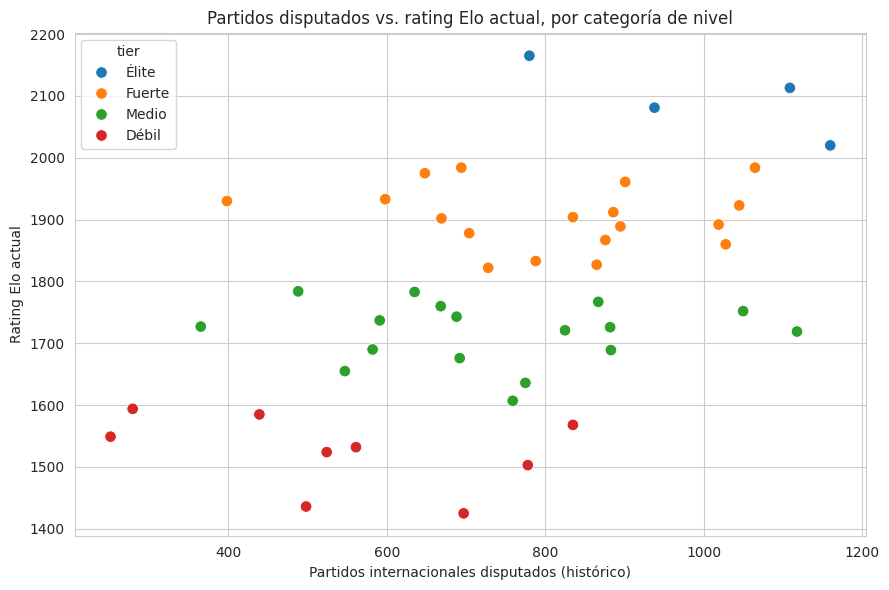

In [28]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_current, x='matches_total', y='rating', hue='tier', s=70, ax=ax)
ax.set_title('Partidos disputados vs. rating Elo actual, por categoría de nivel')
ax.set_xlabel('Partidos internacionales disputados (histórico)')
ax.set_ylabel('Rating Elo actual')
plt.tight_layout()
plt.show()

**Interpretación:** Las selecciones clasificadas en el tier 'Élite' no son necesariamente las que más partidos han disputado, lo que confirma que el rating actual depende más del rendimiento reciente que del volumen histórico de partidos.

### 5.6 Distribución del rating por confederación (boxplot)

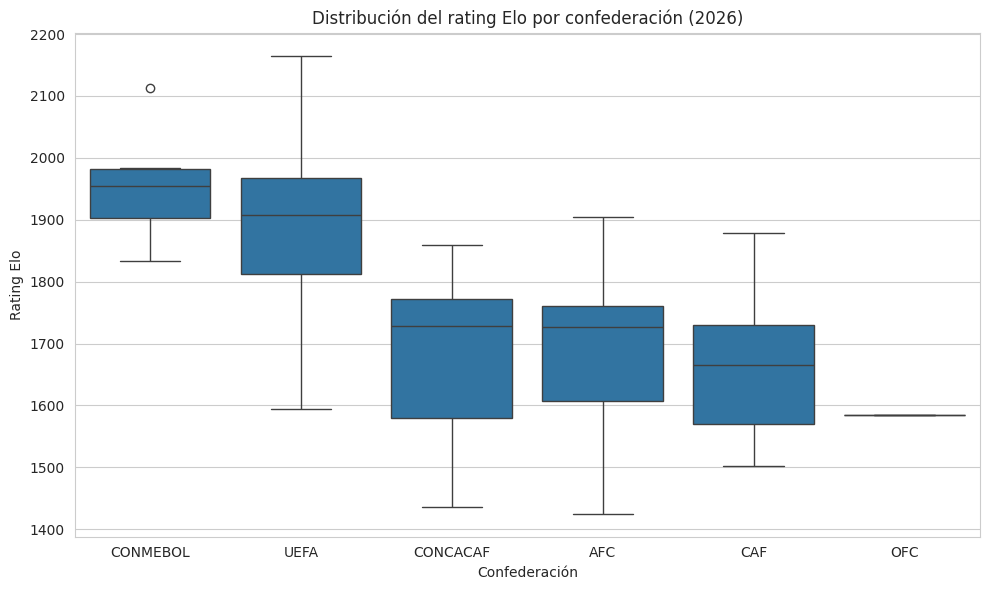

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
order = df_current.groupby('confederation')['rating'].median().sort_values(ascending=False).index
sns.boxplot(data=df_current, x='confederation', y='rating', order=order, ax=ax)
ax.set_title('Distribución del rating Elo por confederación (2026)')
ax.set_xlabel('Confederación')
ax.set_ylabel('Rating Elo')
plt.tight_layout()
plt.show()

**Interpretación:** UEFA presenta la mayor dispersión, con selecciones que van desde el top mundial hasta niveles medios, reflejo de su gran número de plazas (16). CAF y AFC muestran distribuciones más compactas y centradas en niveles medios.

## 6. Conclusiones

A partir del análisis exploratorio realizado sobre el dataset de ratings Elo
históricos de las 48 selecciones clasificadas para el Mundial 2026, se pueden
extraer las siguientes conclusiones:

- **Jerarquía por confederaciones:** UEFA y CONMEBOL concentran a las
  selecciones con mayor rating Elo medio, consolidando su posición histórica
  como las confederaciones más competitivas a nivel mundial.

- **Anfitriones:** México presenta el rating más alto y estable de los tres
  países anfitriones, mientras que Estados Unidos muestra una clara tendencia
  de crecimiento sostenido desde los años 90. No se observa un efecto directo
  del estatus de anfitrión sobre el rating, sino tendencias de fondo previas.

- **Selecciones en declive vs. en ascenso:** existen selecciones históricas
  cuyo rating actual está significativamente por debajo de su pico histórico,
  frente a otras (como España o Argentina) que llegan al Mundial 2026 en una
  fase ascendente según la evolución de su Elo en los últimos años.

- **Experiencia vs. nivel actual:** el número total de partidos disputados a
  lo largo de la historia tiene una correlación débil con el rating actual,
  lo que sugiere que el rendimiento reciente pesa más que la trayectoria
  histórica acumulada.

- **Selecciones debutantes:** Cabo Verde, Curaçao, Jordania y Uzbekistán se
  sitúan por debajo de la media general, pero ninguna en el nivel más bajo de
  clasificación, lo que indica que su presencia en el Mundial responde a una
  mejora real de nivel y no a la casualidad.

En conjunto, el dataset confirma patrones esperables del fútbol internacional
(dominio europeo y sudamericano, dispersión interna en UEFA, debutantes por
debajo de la media) y aporta una base sólida para análisis predictivos de cara
al Mundial 2026.